In [1]:
# langgraph 패키지 설치
# https://docs.langchain.com/oss/python/langgraph/install

In [2]:
# langchain 패키지 설치

In [3]:
# langchain-google-genai 패키지 설치
# https://docs.langchain.com/oss/python/integrations/providers/overview


# Google vertex AI vs Google genai

# Google vertex AI는 엔터프라이즈 용도로 사용하는 패키지 
# 예를들어 결제 정보, 할당량 같은 것을 프로덕트 단에서 사용하려고 할 때 사용

# Google genai는 개인적으로 사용하는 패키지
# 예를들어 모델 호출 같은 것을 개인적으로 사용하려고 할 때 사용

# 따라서 개인적으로 사용하는 경우 Google genai를 사용하는 것이 좋다.




In [1]:
# os 환경 변수 GEMINI API KEY 입력
import os
from dotenv import load_dotenv

load_dotenv()

True

# Agent 구축 기초
https://docs.langchain.com/oss/python/langgraph/quickstart

### 1. Model 및 Tool 정의

In [2]:
# 모델 객체 생성
# https://docs.langchain.com/oss/python/integrations/providers/google

from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview",
)

In [3]:
from langchain.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b

/Users/dohyunkim/Documents/langchain-study/langgraph/.venv/lib/python3.13/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
# tools 정의

tools = [multiply, add, divide]

In [5]:
# model - tool 바인딩
model_with_tools = model.bind_tools(tools)

### 2. State 정의

In [6]:
# State 정의
# https://docs.langchain.com/oss/python/langgraph/quickstart#2-define-state

from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    # 대화 기록은 리스트 형태로 '누적'되도록 add_messages 리듀서 적용
    messages: Annotated[list[AnyMessage], add_messages]
    # 모델 호출 횟수 기록용
    llm_calls: int


### [add_messages 참조](https://reference.langchain.com/python/langgraph/graphs/?_gl=1*ry73wr*_gcl_au*MTQ0NjcwMDQyNS4xNzYxNzg2NzMz*_ga*MjEyNDg4NjgwNC4xNzYyOTI0NjMz*_ga_47WX3HKKY2*czE3NjgyNzQ0NjEkbzI4JGcxJHQxNzY4Mjc2NzA5JGozMyRsMCRoMA..#langgraph.graph.message.add_messages)

### 3. Node 정의

In [7]:
# llm_call 노드

from langchain.messages import SystemMessage

def llm_call(state: State):
    """LLM이 현재 상태를 보고 답변하거나, 도구 사용을 요청하는 작업자"""

    # 시스템 메시지를 맨 앞에 추가하고 기존 대화 기록을 뒤에 붙여서 LLM에게 전송
    response = model_with_tools.invoke(
        [
            SystemMessage(
                content="당신은 사칙연산을 완벽하게 해내는 유능한 Agent입니다."
            )
        ] + state["messages"]
    )

    # 작업이 끝나면, 새로 생성된 메시지 1개와 카운터 1 증가분을 공책에 업데이트
    return {
        "messages": [response],
        "llm_calls": state.get('llm_calls', 0) + 1 # 만약에 초기 값이 없으면 0이 되도록 한다 
    }


In [8]:
# tool 목록 생성

from langchain.messages import ToolMessage

# 도구 이름을 키로, 실제 함수를 값으로 가지는 딕셔너리 준비
tools_by_name = {tool.name: tool for tool in tools}

def tool_node(state: State):
    """LLM이 도구 사용을 요청했을 때, 실제로 함수를 실행하는 작업자"""

    result = []
    # 공책의 맨 마지막 메시지(LLM의 요청장)에서 tool_calls 리스트 꺼내기
    last_message = state["messages"][-1]

    for tool_call in last_message.tool_calls:
        # 1. 도구 이름으로 실제 파이썬 함수 찾기
        tool = tools_by_name[tool_call["name"]]

        # 2. 인자(args)를 넣고 함수 실행
        tool_result = tool.invoke(tool_call["args"])

        # 3. 실행 결과를 ToolMessage로 포장 (tool_call_id를 반드시 맞춰주어야 모델이 인식함)
        result.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))

    # 도구 실행 결과들을 공책에 업데이트
    return {"messages": result}


In [9]:
# tool_node

tool_calls = [
    {"name": "weather", "args": {"city": "Seoul"}, "id": "call_12345"}, # 서울 요청 (ID: 12345)
    {"name": "weather", "args": {"city": "Tokyo"}, "id": "call_67890"}  # 도쿄 요청 (ID: 67890)
]


### 4. 그래프 생성

In [10]:
# 그래프 생성

from langgraph.graph import StateGraph, START

# 1. 빈 작업장(그래프) 도면 펼치기 (공책 양식을 알려줌)
agent_builder = StateGraph(State)

# 2. add_node: 도면에 작업자(노드) 배치하기
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# 3. add_edge: 고정된 연결선(Edge) 긋기
# 시작(START)하자마자 무조건 llm_call 작업자에게 최초로 공책을 넘깁니다.
agent_builder.add_edge(START, "llm_call")
# 도구 실행이 끝나면 결과값을 얻었으니 무조건 다시 llm_call 작업자에게 공책을 넘겨 최종 답변 생성
agent_builder.add_edge("tool_node", "llm_call")



In [11]:
# 조건부 함수 작성

from langgraph.graph import END

def should_continue(state: State):
    """
    LLM의 응답을 보고 다음 단계로 어디를 갈지 결정하는 라우팅 함수
    """
    last_message = state["messages"][-1]

    # LLM이 도구 호출(tool_calls) 요청장을 작성했다면? -> 도구 작업자(tool_node)에게 가라고 문자열 반환
    if last_message.tool_calls:
        return "tool_node"

    # 도구 호출이 없고 최종 답변을 작성했다면? -> 작업 종료(END) 객체 반환
    return END


In [12]:
# 조건부 엣지 연결

# 4. add_conditional_edges: 라우팅 기능을 하는 선 설치
agent_builder.add_conditional_edges(
    "llm_call",         # 1) 출발지: llm_call 작업이 끝나면 무조건 이 라우터 함수가 발동합니다.
    should_continue,    # 2) 라우팅 함수: 위에서 만든 함수가 공책을 보고 어디로 갈지 판단합니다.
    ["tool_node", END]  # 3) 도착지 목록: 갈 수 있는 목적지들을 리스트나 딕셔너리로 명시합니다.
)


In [13]:
# 컴파일 (최종 에이전트 생성)
agent = agent_builder.compile()

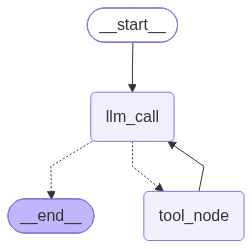

In [14]:
agent

### 실행

In [15]:
from langchain.messages import HumanMessage

messages = [HumanMessage(content="3과 4를 더해줘")]
response = agent.invoke({"messages": messages})

In [16]:
response

{'messages': [HumanMessage(content='3과 4를 더해줘', additional_kwargs={}, response_metadata={}, id='edbc28f1-2d15-454f-92f5-213e83053273'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"b": 4, "a": 3}'}, '__gemini_function_call_thought_signatures__': {'d8f746b4-4bd7-4fbb-8321-115153251767': 'Em8KbQERTTIPpDsYWb9/ijJX4FJqPNq6viKSograpfqXIdSDtb+q/0nWif8IzpldkX6be+UKxiqwrciy61ZC85QqWR7ImjwzewAQj9qsYN94RHTyZXSi8BOopIV9fpLos3gQb6LHBnWmGt6GrUigCvY='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f96c7-c06c-7810-a06e-8740ab3b184e-0', tool_calls=[{'name': 'add', 'args': {'b': 4, 'a': 3}, 'id': 'd8f746b4-4bd7-4fbb-8321-115153251767', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 237, 'output_tokens': 36, 'total_tokens': 273, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 20}}),
  

In [17]:
# 응답 출력

In [18]:
messages = [HumanMessage(content="3과 4를 더한 뒤 7을 곱해줘.")]
response = agent.invoke({"messages": messages})

In [19]:
# Gemini 응답 출력


In [20]:
response["messages"][-1].content[-1]['text']

'3과 4를 더한 결과는 7이며, 여기에 7을 곱하면 최종 결과는 49입니다.'

### OpenAI 기반 Agent

In [21]:
# !pip install -qU langchain-openai

In [22]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano")

In [23]:
model_with_tools = model.bind_tools(tools)

In [24]:
from langchain.messages import SystemMessage

def llm_call(state):
    """LLM이 현재 상태를 보고 답변하거나, 도구 사용을 요청하는 Node"""

    # 시스템 메시지를 맨 앞에 추가하고 기존 대화 기록(state["messages"])을 뒤에 붙여서 LLM에게 전송
    response = model_with_tools.invoke(
        [
            SystemMessage(
                content="당신은 사칙연산을 하는 유능한 Agent입니다."
            )
        ] + state["messages"]
    )

    # 변경된 상태를 반환
    return {
        "messages": [response],
        "llm_calls": state.get('llm_calls', 0) + 1

    }

In [25]:
tools_by_name = {tool.name: tool for tool in tools}

In [26]:
from langchain.messages import ToolMessage

def tool_node(state):
    """LLM이 도구 사용을 요청했을 때, 실제로 도구를 실행하는 단계"""

    result = []
    # 가장 최근 메시지(LLM의 응답)에서 도구 호출 요청(tool_calls)들을 꺼내기
    for tool_call in state["messages"][-1].tool_calls:
        # 1. 도구 이름으로 실제 함수 찾기
        tool = tools_by_name[tool_call["name"]]

        # 2. 함수를 실행하여 결과를 얻기
        tool_result = tool.invoke(tool_call["args"])

        # 3. 결과를 ToolMessage 형태로 포장 (tool_call_id는 필수!)
        result.append(ToolMessage(content=tool_result, tool_call_id=tool_call["id"]))

    # 실행 결과를 대화 기록에 추가
    return {"messages": result}

In [27]:
from langgraph.graph import StateGraph, START

# 1. 워크플로우(그래프) 생성
agent_builder = StateGraph(State)

# 2. 노드(작업자) 배치
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# 3. 엣지(연결선) 연결
agent_builder.add_edge(START, "llm_call")
agent_builder.add_edge("tool_node", "llm_call")

In [28]:
from langgraph.graph import StateGraph, START, END

def should_continue(state: State):
    """
    LLM의 응답을 보고 다음 단계로 어디를 갈지 결정
    """
    messages = state["messages"]
    last_message = messages[-1]

    # LLM이 도구 호출(tool_calls)을 포함한 응답을 보낸 경우
    if last_message.tool_calls:
        return "tool_node"

    # 도구 호출이 없으면 작업 종료
    return END

In [29]:
# 조건부 엣지 연결
agent_builder.add_conditional_edges(
    "llm_call",         # 출발지
    should_continue,    # 판단 로직 함수
    ["tool_node", END]  # 갈 수 있는 목적지들
)

In [30]:
# 컴파일 (최종 에이전트 생성)
agent = agent_builder.compile()

In [31]:
from langchain.messages import HumanMessage

messages = [HumanMessage(content="3과 4를 더해줘")]
response = agent.invoke({"messages": messages})

In [32]:
response

{'messages': [HumanMessage(content='3과 4를 더해줘', additional_kwargs={}, response_metadata={}, id='95952df3-1465-4419-9e89-caa60cc557c2'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 218, 'prompt_tokens': 247, 'total_tokens': 465, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-E5L0fMNrX7vLG0afkhABcX38BDn5z', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f96c7-db08-79b0-bac1-4f072bbfe746-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_vuu4qDTP9FTihMeLsALlL9Dj', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 247, 'output_tokens

In [33]:
# Gemini 기반 Agent 실행 시 response 결과와 다른 것을 확인할 수 있다.